In [189]:
from ucimlrepo import fetch_ucirepo
import keras
from keras.models import Sequential
from keras.layers import Input, Dense
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
# fetch dataset
iris = fetch_ucirepo(id=53)

X = iris.data.features.values
y = iris.data.targets.values.ravel()



In [190]:
# Encode labels to numerical values
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# One-hot the encoded labels
y_onehot = to_categorical(y_encoded)

y_onehot

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0

In [191]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [192]:
# Define the model
model = Sequential([
    Input(shape=(4,)), # Input shape already flat vector
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
    ])

In [193]:
# Define the optimizer with small learning rate to stabilize the learning on the small dataset preventing overshooting
opt = keras.optimizers.RMSprop(learning_rate=0.001)

# Compile the model
model.compile(opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [194]:
# Train the model, shuffle between epochs
history = model.fit(X_scaled, y_onehot, epochs=50, batch_size=8, validation_split=0.2, shuffle=True)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4083 - loss: 0.9764 - val_accuracy: 0.0000e+00 - val_loss: 1.4346
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 0.8935 - val_accuracy: 0.0000e+00 - val_loss: 1.3122
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6083 - loss: 0.8295 - val_accuracy: 0.0000e+00 - val_loss: 1.2024
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6667 - loss: 0.7720 - val_accuracy: 0.1000 - val_loss: 1.0949
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8417 - loss: 0.7194 - val_accuracy: 0.6667 - val_loss: 0.9998
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8500 - loss: 0.6726 - val_accuracy: 0.8000 - val_loss: 0.9264
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8583 - loss: 0.6317 - val_accuracy: 0.8000 - val_loss: 0.8466
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8583 - loss: 0.5961 - val_accuracy: 0.800

In [195]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Final training accuracy:", train_acc)
print("Final validation accuracy:", val_acc)

Final training accuracy: 0.9750000238418579
Final validation accuracy: 0.9333333373069763


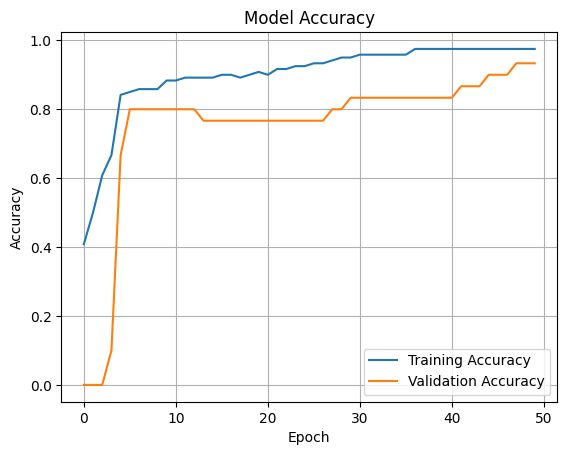

In [197]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()
plt.show()

After fine-tuning the model for a while, the conclusion is that it is inconsistent to get over 95 % validation accuracy. It is just hitting its limits, because the dataset is so small.

As seen from the plot after around 5-6 epochs the model has learned most of the patterns from the data.